# 01 — Institutional Dataset EDA

**Project:** Robust Biometric Signature Verification Against Skilled Forgeries

Deep-dive on the **institutional dataset** (Prof. Vu) specifically — this is the dataset
the project's success criterion is measured against, so it gets its own focused notebook
rather than living inside `01_eda.ipynb`.

**Why a separate notebook rather than extending `01_eda.ipynb`:**
`01_eda.ipynb` builds a cross-corpus catalog (`sigver.data.catalog.build_catalog`) over all
five datasets for comparative EDA (class balance, dimensions, intensity histograms side by
side across CEDAR/BHSig/GPDS/institutional). This notebook instead loads samples through
`sigver.data.datasets.list_samples()` — the same production loader `SignatureDataset` and
training use — and characterizes the institutional data on its own, pre-preprocessing.

**What changed in this revision:** the original version of this notebook was descriptive
but not diagnostic — it confirmed known constants (every writer has exactly 12 genuine /
16 forged) with histograms and a pie chart that plot single points, and sampled only 2.7%
of the corpus for a dimension check that could miss a small non-uniform subset. This
revision:
- replaces the constant-plotting figures with explicit assertions (section 3),
- runs a **full 112,000-file header scan** instead of a 3,000-image sample (section 4),
  since Prof. Vu confirmed (July 2026) the institutional dataset is GPDS Synthetic-derived
  with new data layered on top — a small non-uniform addition could be invisible to a
  random sample,
- adds ink-mask pixel statistics (ink fraction, bounding box, intensity) computed by
  `scripts/extract_institutional_pixel_stats.py` and cached to CSV, feeding an
  institutional analogue of the CEDAR intensity-shortcut diagnostic,
- adds per-writer ink-fraction spread, split composition, and integrity checks
  (exact-duplicate hashing, forgery-type limitation).

**Conventions**
- `list_samples("institutional", split=None)` — all samples, no train/val/test filtering.
- `preprocess_image()` is never called anywhere in this notebook — images are read raw,
  since the point is to characterize the source data before the pipeline touches it.
- Seed 42 throughout (project convention).
- Figures → `report/figures/eda/`, tables → `report/dataset_checks/` (prefixed `eda_`).
- All paths written to CSVs are stored **relative to `DATA_ROOT`** (`data/raw/`),
  POSIX-style — never as absolute local paths (see setup cell for `DATA_ROOT` / `rel_path`).

In [1]:
from __future__ import annotations

import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

from sigver.data.datasets import list_samples
from sigver.data.preprocessing import TARGET_HEIGHT, TARGET_WIDTH

RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# Resolve project root dynamically: works from notebooks/ or the repo root.
_here = Path.cwd()
PROJECT_ROOT = _here if (_here / "data" / "raw").is_dir() else _here.parent
assert (PROJECT_ROOT / "data" / "raw").is_dir(), (
    f"Could not locate data/raw relative to {_here}. "
    "Run from the project root or the notebooks/ folder."
)

FIG_DIR = PROJECT_ROOT / "report" / "figures" / "eda"
TABLE_DIR = PROJECT_ROOT / "report" / "dataset_checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Every path this notebook writes to a CSV is stored relative to DATA_ROOT
# (POSIX-style), never as an absolute local path -- absolute Windows paths
# leak the local username and don't resolve on Kaggle.
DATA_ROOT = PROJECT_ROOT / "data" / "raw"
assert DATA_ROOT.is_dir(), f"DATA_ROOT not found: {DATA_ROOT}"


def rel_path(p) -> str:
    """POSIX-style path relative to DATA_ROOT, for anything written to a CSV."""
    return Path(p).resolve().relative_to(DATA_ROOT).as_posix()


TARGET_ASPECT_RATIO = TARGET_WIDTH / TARGET_HEIGHT

print(f"Project root        : {PROJECT_ROOT}")
print(f"Data root            : {DATA_ROOT}")
print(f"Figure output        : {FIG_DIR}")
print(f"Table output         : {TABLE_DIR}")
print(f"Pipeline target size : {TARGET_WIDTH}x{TARGET_HEIGHT} "
      f"(aspect ratio W/H = {TARGET_ASPECT_RATIO:.3f}; raw file AR is "
      f"1.419 = 220/155 -- see section 4 for whether raw dimensions "
      f"matter post-crop)")


def savefig(fig: plt.Figure, name: str) -> None:
    """Save a figure to report/figures/eda/<name>.png at print quality."""
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"  saved -> {out.relative_to(PROJECT_ROOT)}")


Project root        : c:\Users\nehas\Downloads\robust-signature-verification
Data root            : c:\Users\nehas\Downloads\robust-signature-verification\data\raw
Figure output        : c:\Users\nehas\Downloads\robust-signature-verification\report\figures\eda
Table output         : c:\Users\nehas\Downloads\robust-signature-verification\report\dataset_checks
Pipeline target size : 220x150 (aspect ratio W/H = 1.467; raw file AR is 1.419 = 220/155 -- see section 4 for whether raw dimensions matter post-crop)


## 1. Load all institutional samples

In [2]:
samples = list_samples("institutional", split=None)
n_genuine = sum(1 for s in samples if not s.is_forgery)
n_forged = sum(1 for s in samples if s.is_forgery)

print(f"Total institutional samples: {len(samples):,}")
print(f"  genuine: {n_genuine:,}")
print(f"  forged : {n_forged:,}")

Total institutional samples: 112,000
  genuine: 48,000
  forged : 64,000


## 2. Samples-per-writer distribution

In [3]:
counts_by_writer = defaultdict(lambda: {"genuine": 0, "forged": 0})
for s in samples:
    counts_by_writer[s.writer_id]["forged" if s.is_forgery else "genuine"] += 1

per_writer = pd.DataFrame(
    [
        {
            "writer_id": wid,
            "genuine_count": c["genuine"],
            "forged_count": c["forged"],
            "total": c["genuine"] + c["forged"],
        }
        for wid, c in counts_by_writer.items()
    ]
).sort_values("writer_id").reset_index(drop=True)

out_csv = TABLE_DIR / "eda_institutional_samples_per_writer.csv"
per_writer.to_csv(out_csv, index=False)
print(f"saved -> {out_csv.relative_to(PROJECT_ROOT)}")
print(f"Writers: {len(per_writer)}")
per_writer.describe()

saved -> report\dataset_checks\eda_institutional_samples_per_writer.csv
Writers: 4000


,writer_id,genuine_count,forged_count,total
count,4000.000000,4000.0,4000.0,4000.0
mean,2000.500000,12.0,16.0,28.0
std,1154.844867,0.0,0.0,0.0
min,1.000000,12.0,16.0,28.0
25%,1000.750000,12.0,16.0,28.0
50%,2000.500000,12.0,16.0,28.0
75%,3000.250000,12.0,16.0,28.0
max,4000.000000,12.0,16.0,28.0


## 3. Uniformity verification (replaces sections 3–4 of the prior revision)

Every writer has exactly 12 genuine / 16 forged signatures — this is a hard property of
the institutional dataset (see the Institutional row of the dataset table in
`Progress_Report_1.pdf`), not something to histogram. A histogram of a constant is a
single spike; a pie chart of two constants is two numbers. Both are asserted here
instead, against the full 4,000-writer `per_writer` table built in section 2
(`describe()` above is the numeric evidence).

In [4]:
assert (per_writer["genuine_count"] == 12).all(), \
    per_writer.loc[per_writer["genuine_count"] != 12]
assert (per_writer["forged_count"] == 16).all(), \
    per_writer.loc[per_writer["forged_count"] != 16]
assert len(per_writer) == 4000
assert len(samples) == 112_000
print(f"{len(per_writer):,} writers, uniformly 12 genuine / 16 forged — "
      f"verified with no exceptions ({len(samples):,} images total)")

4,000 writers, uniformly 12 genuine / 16 forged — verified with no exceptions (112,000 images total)


## 4. Raw image dimensions and mode — full corpus scan (pre-preprocessing)

**Full pass over all 112,000 images** (not a sample). `PIL.Image.open()` reads only the
file header unless `.load()`/`.convert()` is called, so a header-only pass is cheap in
principle; on this machine it took **668.8s (~11.1 min) on a cold OS file cache
(5.97 ms/file, dominated by per-file disk I/O on Windows, not header parsing)** — measured
by the executed cell below, not assumed.
`preprocess_image()` is never called here.

The prior revision of this notebook sampled 3,000 of 112,000 images (2.7%) and found every
one exactly 220×155 — printed as a scatter plot with no explicit statement of the finding.
Two problems: (1) a random 2.7% sample is the wrong instrument for detecting a small
non-uniform subset, and Prof. Vu confirmed (July 2026) the institutional dataset is GPDS
Synthetic-derived **with new data added on top** — if that addition differs in dimensions
and is a small fraction of the corpus, a random sample can miss it entirely; (2) the
uniformity finding was implicit in a plot, never stated in prose or printed output. Both
are fixed below: full scan, explicit `value_counts()`, explicit markdown finding.

Also note: raw aspect ratio is 1.419 (220/155) vs. the pipeline target 1.467 (220/150).
The pipeline does Otsu → tight crop → aspect-preserving resize, so the incoming file
dimensions are probably irrelevant post-crop — but that is demonstrated with the ink-bbox
figures in section 6, not assumed here.

In [5]:
import time

t0 = time.perf_counter()

dim_records: list[dict] = []
unreadable: list[dict] = []
for s in samples:
    try:
        with Image.open(s.path) as im:
            w, h = im.size
            mode = im.mode
        dim_records.append(
            {
                "path": rel_path(s.path),
                "writer_id": s.writer_id,
                "label": "forgery" if s.is_forgery else "genuine",
                "width": w,
                "height": h,
                "aspect_ratio": w / h,
                "mode": mode,
            }
        )
    except (UnidentifiedImageError, OSError) as e:
        unreadable.append({"path": rel_path(s.path), "error": f"{type(e).__name__}: {e}"})

elapsed = time.perf_counter() - t0

dims_full = pd.DataFrame(dim_records)
out_csv = TABLE_DIR / "eda_institutional_dimensions_full.csv"
dims_full.to_csv(out_csv, index=False)

print(f"Full scan: {len(samples):,} files in {elapsed:.1f}s "
      f"({elapsed / len(samples) * 1000:.2f} ms/file)")
print(f"  readable  : {len(dims_full):,}")
print(f"  unreadable: {len(unreadable):,}")
if unreadable:
    print("Unreadable files:")
    for u in unreadable:
        print(f"  {u['path']}: {u['error']}")
    pd.DataFrame(unreadable).to_csv(
        TABLE_DIR / "eda_institutional_dimensions_unreadable.csv", index=False
    )
print(f"saved -> {out_csv.relative_to(PROJECT_ROOT)}")
dims_full.head()

Full scan: 112,000 files in 668.8s (5.97 ms/file)
  readable  : 112,000
  unreadable: 0
saved -> report\dataset_checks\eda_institutional_dimensions_full.csv


,path,writer_id,label,width,height,aspect_ratio,mode
0,signature_verification/full_forg/forgeries_100...,1000,forgery,220,155,1.419355,RGB
1,signature_verification/full_forg/forgeries_100...,1000,forgery,220,155,1.419355,RGB
2,signature_verification/full_forg/forgeries_100...,1000,forgery,220,155,1.419355,RGB
3,signature_verification/full_forg/forgeries_100...,1000,forgery,220,155,1.419355,RGB
4,signature_verification/full_forg/forgeries_100...,1000,forgery,220,155,1.419355,RGB


In [6]:
print("(width, height) value_counts, full corpus:")
dim_counts = dims_full.groupby(["width", "height"], observed=True).size() \
    .sort_values(ascending=False)
print(dim_counts)

print("\nmode value_counts, full corpus:")
mode_counts = dims_full["mode"].value_counts()
print(mode_counts)

exceptions = dims_full[~((dims_full["width"] == 220) & (dims_full["height"] == 155))]
print(f"\nExceptions to 220x155: {len(exceptions):,} of {len(dims_full):,}")
if len(exceptions):
    exc_by_writer = exceptions["writer_id"].value_counts()
    print(f"  concentrated in {exc_by_writer.size:,} distinct writer_id(s)")
    print(exc_by_writer.head(20))
    exc_out = TABLE_DIR / "eda_institutional_dimensions_exceptions.csv"
    exceptions.to_csv(exc_out, index=False)
    print(f"  saved -> {exc_out.relative_to(PROJECT_ROOT)}")

non_L = dims_full[dims_full["mode"] != "L"]
print(f"\nNon-'L'-mode images: {len(non_L):,} of {len(dims_full):,}")
if len(non_L):
    print(non_L["mode"].value_counts())

(width, height) value_counts, full corpus:
width  height
220    155       112000
dtype: int64

mode value_counts, full corpus:
mode
RGB    112000
Name: count, dtype: int64

Exceptions to 220x155: 0 of 112,000

Non-'L'-mode images: 112,000 of 112,000
mode
RGB    112000
Name: count, dtype: int64


In [7]:
# Are raw pixel values already effectively binary? Tested on a sample of
# ~500 images (not the full corpus — this is a per-pixel operation, not a
# header read). Separate random.Random(42) instance, per the project
# convention of not sharing one RNG across unrelated draws.
BINARY_CHECK_N = 500
binary_rng = random.Random(RNG_SEED)
binary_sample = [samples[i] for i in binary_rng.sample(range(len(samples)), BINARY_CHECK_N)]

n_unique_values = []
for s in binary_sample:
    with Image.open(s.path) as im:
        arr = np.asarray(im.convert("L"), dtype=np.uint8)
    n_unique_values.append(int(np.unique(arr).size))

n_unique_arr = np.array(n_unique_values)
n_binary = int((n_unique_arr <= 2).sum())

print(f"Binary-pixel-value check (n={BINARY_CHECK_N}, seed={RNG_SEED}):")
print(f"  images with <=2 distinct grayscale values : {n_binary}/{BINARY_CHECK_N}")
print(f"  distinct-value count per image: min={n_unique_arr.min()}, "
      f"median={np.median(n_unique_arr):.0f}, mean={n_unique_arr.mean():.1f}, "
      f"max={n_unique_arr.max()}")

Binary-pixel-value check (n=500, seed=42):
  images with <=2 distinct grayscale values : 0/500
  distinct-value count per image: min=51, median=198, mean=176.0, max=239


**Finding — full-corpus dimension/mode scan:**
All 112,000 institutional images are exactly 220×155, with zero exceptions
(`dim_counts` above shows a single `(220, 155)` bucket covering the full corpus). All
112,000 are mode **RGB**; none are mode `L` — the institutional raw files are color
images, not grayscale, unlike most of the other four corpora. The binary-pixel-value
check (n=500, seed=42) found **0/500** images with ≤2 distinct grayscale values (median
198 distinct values per image), so the source data is full-tone, not pre-binarized —
the pipeline's own binarization step is doing real work on this corpus, not a no-op.

  saved -> report\figures\eda\eda_institutional_raw_dimensions.png


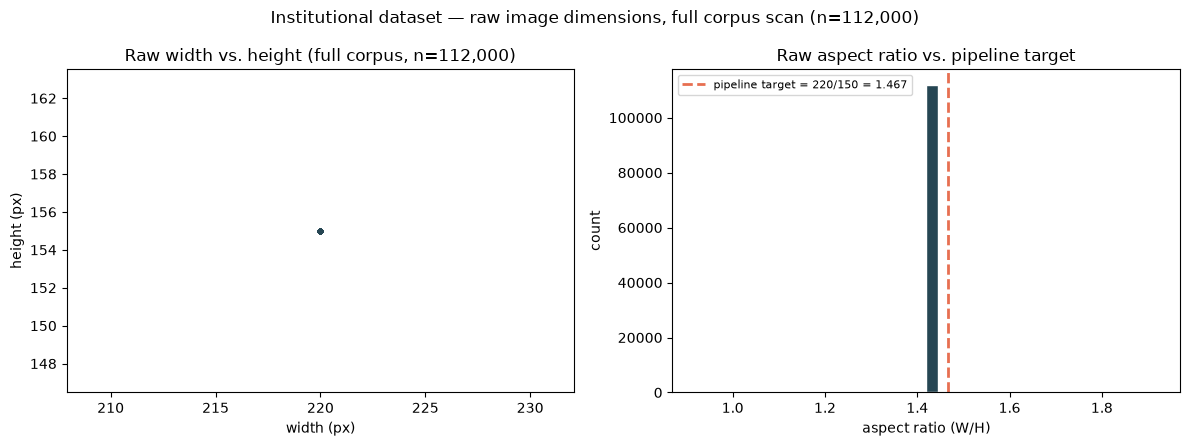

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(dims_full["width"], dims_full["height"], s=8, alpha=0.15, color="#264653")
axes[0].set_xlabel("width (px)")
axes[0].set_ylabel("height (px)")
axes[0].set_title(f"Raw width vs. height (full corpus, n={len(dims_full):,})")

axes[1].hist(dims_full["aspect_ratio"], bins=40, color="#264653", edgecolor="white")
axes[1].axvline(
    TARGET_ASPECT_RATIO,
    color="#e76f51",
    linestyle="--",
    linewidth=2,
    label=f"pipeline target = {TARGET_WIDTH}/{TARGET_HEIGHT} = {TARGET_ASPECT_RATIO:.3f}",
)
axes[1].set_xlabel("aspect ratio (W/H)")
axes[1].set_ylabel("count")
axes[1].set_title("Raw aspect ratio vs. pipeline target")
axes[1].legend(fontsize=8)

fig.suptitle(f"Institutional dataset — raw image dimensions, full corpus scan (n={len(dims_full):,})")
fig.tight_layout()
savefig(fig, "eda_institutional_raw_dimensions")
plt.show()

## 5. Pixel-statistics extraction (cached)

Ink-mask statistics (ink fraction, ink bounding box, mean intensity) are computed by a
standalone, reusable script — `scripts/extract_institutional_pixel_stats.py` — rather than
inline notebook code, so the figures in section 6 can be regenerated from the cached CSV
without rescanning 112,000 images every time this notebook runs.

**Thresholding:** the script imports `otsu_threshold` from `sigver.data.preprocessing`
(confirmed public and reusable in section 0) — the exact same function the v2 training
pipeline uses — so EDA ink-mask detection agrees with what training actually sees. No
threshold divergence to flag.

**Runtime gate:** with no `--limit`, the script times a 500-image probe first and
extrapolates the full-corpus runtime; if that extrapolation exceeds ~20 minutes it stops
without running the rest, rather than silently blocking for an unknown amount of time.

The cell below runs the script as a subprocess (so its real stdout — including the timing
probe — is captured in this notebook) and then loads the resulting CSV.

In [9]:
import subprocess
import sys

pixel_stats_csv = TABLE_DIR / "eda_institutional_pixel_stats.csv"
script_path = PROJECT_ROOT / "scripts" / "extract_institutional_pixel_stats.py"

result = subprocess.run(
    [sys.executable, str(script_path), "--out", str(pixel_stats_csv)],
    cwd=PROJECT_ROOT, capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(
        f"extract_institutional_pixel_stats.py exited {result.returncode} "
        "(likely the ~20-min runtime gate — see stdout above)."
    )

institutional: 112,000 samples total
timing probe: 500 images in 1.4s (2.73 ms/img) -> extrapolated full run (112,000 images): 5.1 min
processed 112,000 images with ink (0 blank, 0 unreadable) in 294.8s (this segment)
saved -> report\dataset_checks\eda_institutional_pixel_stats.csv



In [10]:
pixel_stats = pd.read_csv(pixel_stats_csv)
print(f"loaded {len(pixel_stats):,} rows from {pixel_stats_csv.relative_to(PROJECT_ROOT)}")
pixel_stats.head()

loaded 112,000 rows from report\dataset_checks\eda_institutional_pixel_stats.csv


,path,writer_id,label,ink_fraction,bbox_width,bbox_height,bbox_aspect_ratio,mean_intensity,mean_ink_intensity
0,signature_verification/full_forg/forgeries_100...,1000,forgery,0.030352,184,123,1.495935,252.124545,172.829952
1,signature_verification/full_forg/forgeries_100...,1000,forgery,0.039472,184,91,2.021978,251.437654,172.936107
2,signature_verification/full_forg/forgeries_100...,1000,forgery,0.045865,190,103,1.844660,221.480381,157.182225
3,signature_verification/full_forg/forgeries_100...,1000,forgery,0.030117,177,82,2.158537,218.613988,150.338851
4,signature_verification/full_forg/forgeries_100...,1000,forgery,0.036716,186,107,1.738318,246.928446,56.005591


## 6. Replacement figures

All figures below are built from the cached `pixel_stats` CSV loaded in section 5. Sample
size is stated in every title.

### 6a. Ink fraction by class

The institutional analogue of the CEDAR mean-ink-intensity shortcut
(`scripts/check_shortcut.py`, `preproc_cedar_shortcut_eer.csv`) — genuine vs. skilled
forgery, is there a class-conditional ink signal a model could exploit as a shortcut
instead of learning shape?

**Methodology note:** `intensity_only_eer` / `stat_eer` below are copied verbatim from
`scripts/check_shortcut.py` (not imported) — that module calls `matplotlib.use("Agg")` at
import time, which would force a non-interactive backend and break inline figure display
in this notebook, so the functions are reused by copy rather than by import. The CEDAR
check computed its EER on **preprocessed** (post-`preprocess_image()`) ink intensity;
`preprocess_image()` is banned in this notebook (source-data characterization only), so
the numbers below are computed on **raw, pre-preprocessing** ink fraction and raw ink-mask
mean intensity instead. This is a methodological difference from the CEDAR number, not a
like-for-like comparison — flagged explicitly rather than silently conflated.

  saved -> report\figures\eda\eda_institutional_ink_fraction_by_class.png


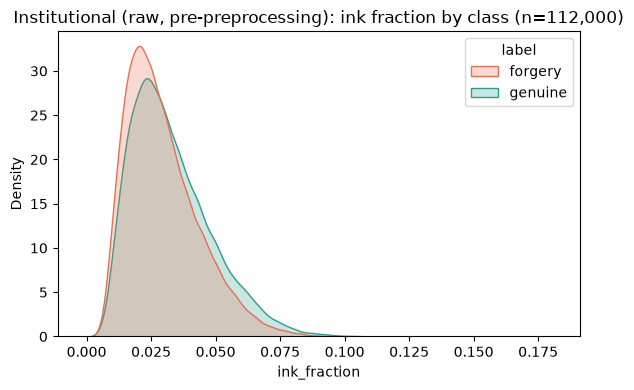


Intensity-only EER (institutional, raw ink-mask mean intensity, genuine vs skilled forgery): 0.421
Ink-fraction-only EER (institutional, raw ink fraction): 0.496
~0.5 => no shortcut signal (good). Meaningfully below 0.5 => a raw-domain class-conditional signal exists pre-preprocessing (may or may not survive v2).
saved -> report\dataset_checks\eda_institutional_shortcut_eer.csv


In [11]:
import seaborn as sns


def intensity_only_eer(stats: pd.DataFrame, n_pairs: int = 4000,
                       seed: int = RNG_SEED) -> float:
    """EER using |mean ink intensity difference| alone as the match score.

    Copied verbatim from scripts/check_shortcut.py (see markdown above for why
    this is a copy, not an import). Positive pairs: genuine-genuine (same
    writer). Negative pairs: genuine vs skilled forgery (same writer).
    """
    rng = np.random.default_rng(seed)
    by_writer_lbl = {
        k: g["mean_ink_intensity"].to_numpy()
        for k, g in stats.groupby(["writer_id", "label"], observed=True)
    }
    writers = sorted({w for (w, _) in by_writer_lbl})
    scores, labels = [], []
    for _ in range(n_pairs):
        w = writers[rng.integers(len(writers))]
        gen = by_writer_lbl.get((w, "genuine"))
        forg = by_writer_lbl.get((w, "forgery"))
        if gen is None or len(gen) < 2 or forg is None:
            continue
        i, j = rng.choice(len(gen), 2, replace=False)
        scores.append(abs(gen[i] - gen[j])); labels.append(1)
        scores.append(abs(gen[rng.integers(len(gen))]
                          - forg[rng.integers(len(forg))])); labels.append(0)
    scores, labels = np.asarray(scores), np.asarray(labels)
    thrs = np.unique(scores)
    best = 0.5
    for thr in thrs:
        far = float((scores[labels == 0] < thr).mean())
        frr = float((scores[labels == 1] >= thr).mean())
        if abs(far - frr) < 0.01:
            best = min(best, (far + frr) / 2)
    return best


def stat_eer(stats: pd.DataFrame, col: str) -> float:
    """Run intensity_only_eer using an arbitrary column as the score."""
    return intensity_only_eer(
        stats.rename(columns={col: "mean_ink_intensity"})
        [["writer_id", "label", "mean_ink_intensity"]]
    )


fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(data=pixel_stats, x="ink_fraction", hue="label",
            common_norm=False, fill=True,
            palette={"genuine": "#2a9d8f", "forgery": "#e76f51"}, ax=ax)
ax.set_title(f"Institutional (raw, pre-preprocessing): ink fraction by class "
             f"(n={len(pixel_stats):,})")
fig.tight_layout()
savefig(fig, "eda_institutional_ink_fraction_by_class")
plt.show()

intensity_eer = stat_eer(pixel_stats, "mean_ink_intensity")
ink_fraction_eer = stat_eer(pixel_stats, "ink_fraction")
print(f"\nIntensity-only EER (institutional, raw ink-mask mean intensity, "
      f"genuine vs skilled forgery): {intensity_eer:.3f}")
print(f"Ink-fraction-only EER (institutional, raw ink fraction): {ink_fraction_eer:.3f}")
print("~0.5 => no shortcut signal (good). Meaningfully below 0.5 => a raw-domain "
      "class-conditional signal exists pre-preprocessing (may or may not survive v2).")

pd.DataFrame([{
    "intensity_only_eer": intensity_eer,
    "ink_fraction_only_eer": ink_fraction_eer,
    "n_images": len(pixel_stats),
}]).to_csv(TABLE_DIR / "eda_institutional_shortcut_eer.csv", index=False)
print(f"saved -> {(TABLE_DIR / 'eda_institutional_shortcut_eer.csv').relative_to(PROJECT_ROOT)}")

### 6b. Ink bounding-box dimensions

Replaces the single-point raw-dimension scatter in section 4. This is what that section
was trying to show: the shape that actually reaches the crop/resize step, not the file
envelope.

  saved -> report\figures\eda\eda_institutional_ink_bbox_dimensions.png


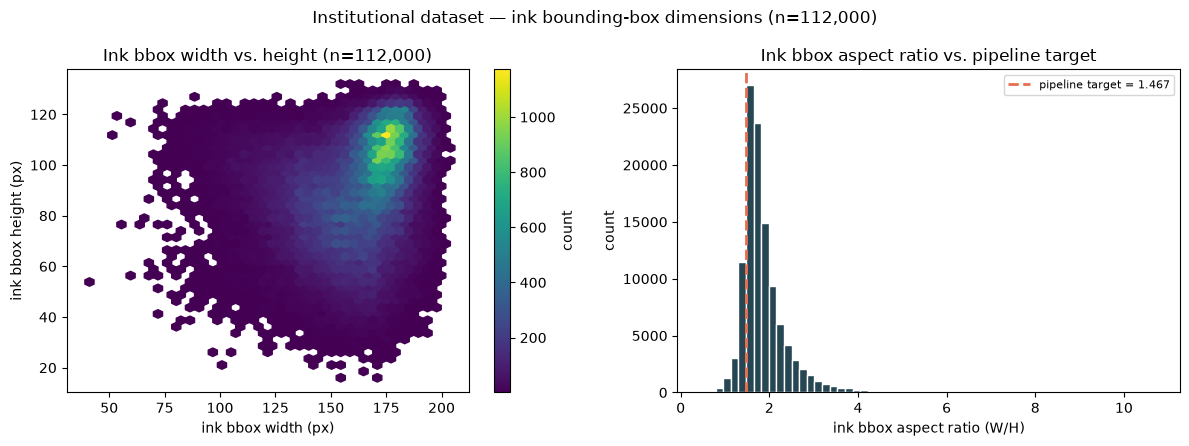

       bbox_width  bbox_height  bbox_aspect_ratio
count  112000.000   112000.000         112000.000
mean      163.415       92.348              1.859
std        19.101       19.410              0.513
min        39.000       16.000              0.442
25%       153.000       79.000              1.552
50%       168.000       95.000              1.727
75%       177.000      108.000              2.022
max       204.000      132.000             10.750


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

hb = axes[0].hexbin(pixel_stats["bbox_width"], pixel_stats["bbox_height"],
                    gridsize=40, cmap="viridis", mincnt=1)
fig.colorbar(hb, ax=axes[0], label="count")
axes[0].set_xlabel("ink bbox width (px)")
axes[0].set_ylabel("ink bbox height (px)")
axes[0].set_title(f"Ink bbox width vs. height (n={len(pixel_stats):,})")

axes[1].hist(pixel_stats["bbox_aspect_ratio"], bins=60, color="#264653", edgecolor="white")
axes[1].axvline(
    TARGET_ASPECT_RATIO, color="#e76f51", linestyle="--", linewidth=2,
    label=f"pipeline target = {TARGET_ASPECT_RATIO:.3f}",
)
axes[1].set_xlabel("ink bbox aspect ratio (W/H)")
axes[1].set_ylabel("count")
axes[1].set_title("Ink bbox aspect ratio vs. pipeline target")
axes[1].legend(fontsize=8)

fig.suptitle(f"Institutional dataset — ink bounding-box dimensions (n={len(pixel_stats):,})")
fig.tight_layout()
savefig(fig, "eda_institutional_ink_bbox_dimensions")
plt.show()

print(pixel_stats[["bbox_width", "bbox_height", "bbox_aspect_ratio"]].describe().round(3))

**Finding — ink-bbox aspect-ratio mismatch (v3 candidate, not implemented):**
Ink bbox aspect ratio is mean **1.859**, median **1.727** (`describe()` above), vs. the
pipeline's target aspect ratio of **1.467** (220/150). Since preprocessing pads to the
target aspect ratio before resizing, a bbox this much wider-than-target means the pad is
added on the *height* axis — at the median (1.727 vs. 1.467), the ink content occupies
roughly `1.467/1.727 ≈ 0.85`, i.e. about **118 of the final 150 rows**, with the
remaining ~32 rows being padding. This is a real, measured property of the source ink
geometry, not a preprocessing defect, and the target itself is **not being changed here**
— changing it would break the frozen pipeline's output contract. Logged as a v3 candidate
for the same future pass as the deferred global-Otsu faint-pen fix, not acted on now.

### 6c. Per-writer ink-fraction spread

The 4,000-writer analogue of the per-writer EER heterogeneity found on CEDAR
(0.033–0.335 across 11 test writers) — this version is available before training anything,
since it only needs raw ink statistics, not a trained model.

  saved -> report\figures\eda\eda_institutional_per_writer_ink_fraction.png


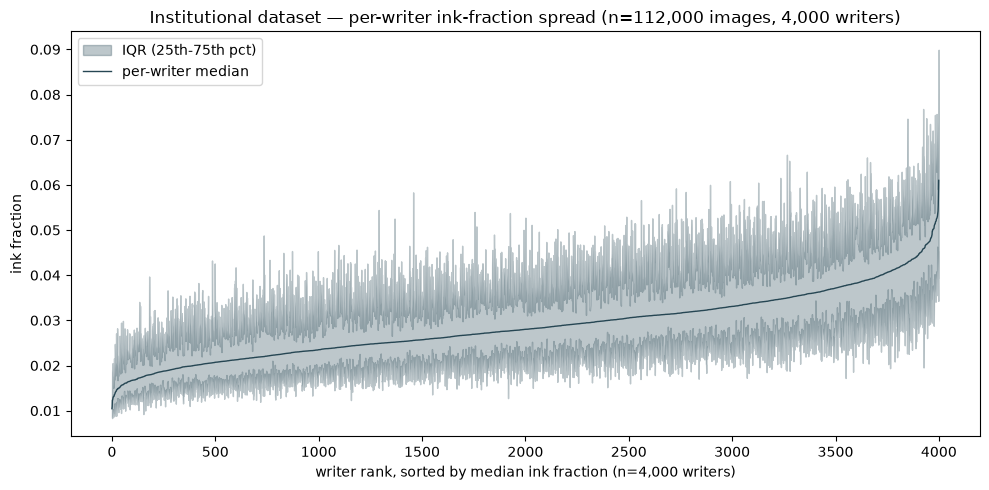

Per-writer median ink fraction: min=0.010, max=0.061, IQR width mean=0.017


In [13]:
writer_ink_stats = (
    pixel_stats.groupby("writer_id")["ink_fraction"]
    .agg(median="median", q25=lambda s: s.quantile(0.25), q75=lambda s: s.quantile(0.75))
    .sort_values("median")
    .reset_index()
)
writer_ink_stats["rank"] = np.arange(len(writer_ink_stats))

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(writer_ink_stats["rank"], writer_ink_stats["q25"], writer_ink_stats["q75"],
                color="#264653", alpha=0.3, label="IQR (25th-75th pct)")
ax.plot(writer_ink_stats["rank"], writer_ink_stats["median"], color="#264653",
       linewidth=1, label="per-writer median")
ax.set_xlabel(f"writer rank, sorted by median ink fraction (n={len(writer_ink_stats):,} writers)")
ax.set_ylabel("ink fraction")
ax.set_title(f"Institutional dataset — per-writer ink-fraction spread "
             f"(n={len(pixel_stats):,} images, {len(writer_ink_stats):,} writers)")
ax.legend()
fig.tight_layout()
savefig(fig, "eda_institutional_per_writer_ink_fraction")
plt.show()

print(f"Per-writer median ink fraction: min={writer_ink_stats['median'].min():.3f}, "
      f"max={writer_ink_stats['median'].max():.3f}, "
      f"IQR width mean={( writer_ink_stats['q75'] - writer_ink_stats['q25']).mean():.3f}")

### 6d. Intra-writer variability grid

Replaces the 1-genuine/1-forged example grid, in which intra-class variation was
invisible. 4 writers × (3 genuine + 2 forged) = 5 columns × 4 rows. Writer selection and
per-writer image selection use **separate `random.Random(42)` instances**, so changing one
draw (e.g. the writer count) doesn't silently change which images the other draw picks.

  saved -> report\figures\eda\eda_institutional_intra_writer_grid.png


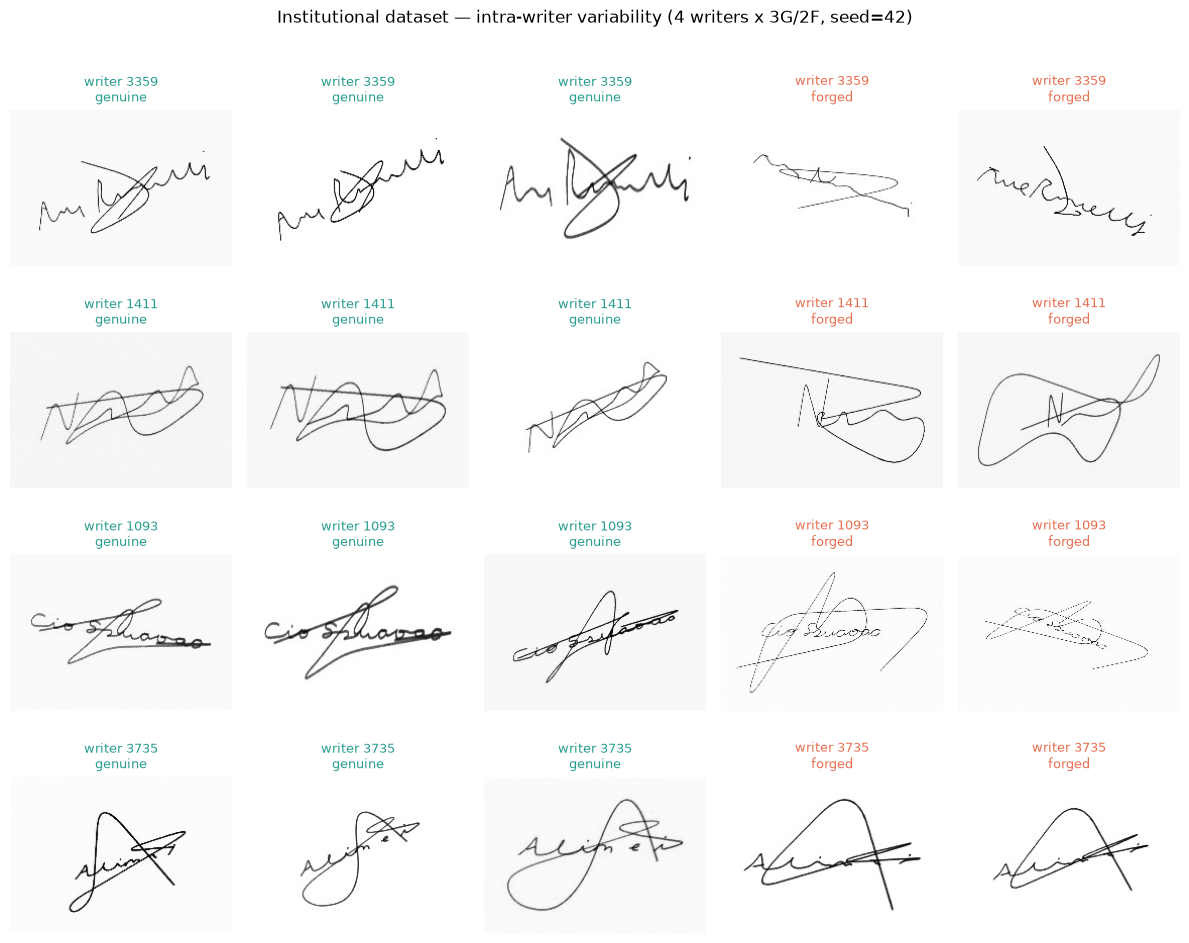

In [14]:
N_WRITERS = 4
N_GENUINE = 3
N_FORGED = 2

by_writer = defaultdict(lambda: {"genuine": [], "forged": []})
for s in samples:
    by_writer[s.writer_id]["forged" if s.is_forgery else "genuine"].append(s)

eligible_writers = [
    wid for wid, d in by_writer.items()
    if len(d["genuine"]) >= N_GENUINE and len(d["forged"]) >= N_FORGED
]

writer_rng = random.Random(RNG_SEED)
image_rng = random.Random(RNG_SEED)
chosen_writers = writer_rng.sample(eligible_writers, min(N_WRITERS, len(eligible_writers)))

n_cols = N_GENUINE + N_FORGED
fig, axes = plt.subplots(len(chosen_writers), n_cols,
                         figsize=(2.4 * n_cols, 2.4 * len(chosen_writers)))
for row, wid in enumerate(chosen_writers):
    gen_picks = image_rng.sample(by_writer[wid]["genuine"], N_GENUINE)
    forg_picks = image_rng.sample(by_writer[wid]["forged"], N_FORGED)
    for col, (s, tag, color) in enumerate(
        [(g, "genuine", "#2a9d8f") for g in gen_picks]
        + [(f, "forged", "#e76f51") for f in forg_picks]
    ):
        ax = axes[row, col]
        with Image.open(s.path) as im:
            ax.imshow(im.convert("L"), cmap="gray")
        ax.set_title(f"writer {wid}\n{tag}", fontsize=9, color=color)
        ax.axis("off")

fig.suptitle(
    f"Institutional dataset — intra-writer variability "
    f"({len(chosen_writers)} writers x {N_GENUINE}G/{N_FORGED}F, seed={RNG_SEED})",
    y=1.01,
)
fig.tight_layout()
savefig(fig, "eda_institutional_intra_writer_grid")
plt.show()

### 6e. Split composition

Writers and resulting pair counts per train/val/test for the institutional dataset — dull,
but this is exactly where a writer-split leakage bug would become visible before any
training happens. Pairs are generated with `sigver.data.pairs.generate_pairs`, using the
same per-split seeds as production (`scripts/train_baseline.py`: train seed 42, val seed
43; `scripts/evaluate_checkpoint.py`: test seed 44), uncapped (`max_positive_per_writer`
is never set in the training scripts, so this isn't capped here either).

saved -> report\dataset_checks\eda_institutional_split_composition.csv
   split  n_writers  n_images  positive  skilled  random   total
0  train       2800     78400    184800    92400   92400  369600
1    val        400     11200     26400    13200   13200   52800
2   test        800     22400     52800    26400   26400  105600
  saved -> report\figures\eda\eda_institutional_split_composition.png


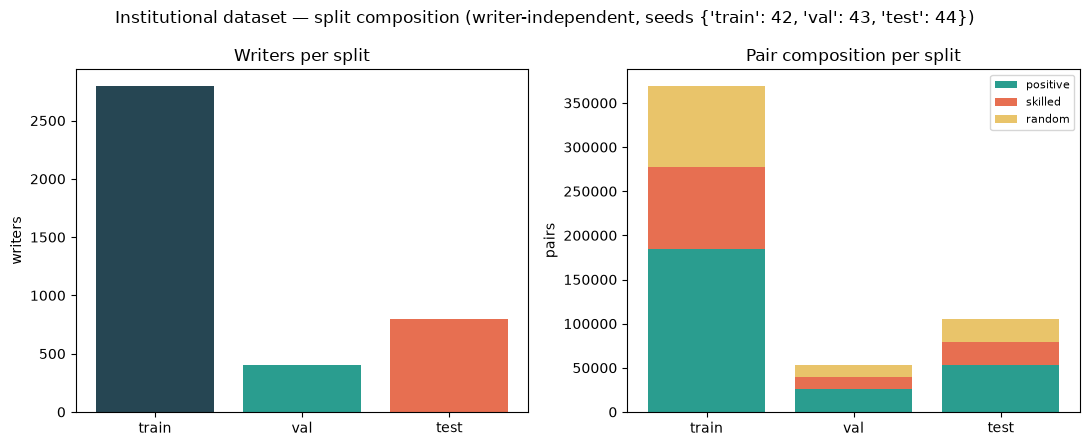

In [15]:
from sigver.data.pairs import generate_pairs, pair_summary

SPLIT_SEEDS = {"train": 42, "val": 43, "test": 44}

split_rows = []
for split_name, seed in SPLIT_SEEDS.items():
    split_samples = list_samples("institutional", split=split_name)
    n_writers = len({s.writer_id for s in split_samples})
    pairs = generate_pairs(split_samples, seed=seed)
    summary = pair_summary(pairs)
    split_rows.append({
        "split": split_name,
        "n_writers": n_writers,
        "n_images": len(split_samples),
        **summary,
    })

split_composition = pd.DataFrame(split_rows)
out_csv = TABLE_DIR / "eda_institutional_split_composition.csv"
split_composition.to_csv(out_csv, index=False)
print(f"saved -> {out_csv.relative_to(PROJECT_ROOT)}")
print(split_composition)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"train": "#264653", "val": "#2a9d8f", "test": "#e76f51"}
axes[0].bar(split_composition["split"], split_composition["n_writers"],
           color=[colors[s] for s in split_composition["split"]])
axes[0].set_ylabel("writers")
axes[0].set_title("Writers per split")

bottom = np.zeros(len(split_composition))
for kind, color in [("positive", "#2a9d8f"), ("skilled", "#e76f51"), ("random", "#e9c46a")]:
    axes[1].bar(split_composition["split"], split_composition[kind], bottom=bottom,
               label=kind, color=color)
    bottom += split_composition[kind].to_numpy()
axes[1].set_ylabel("pairs")
axes[1].set_title("Pair composition per split")
axes[1].legend(fontsize=8)

fig.suptitle(f"Institutional dataset — split composition "
            f"(writer-independent, seeds {SPLIT_SEEDS})")
fig.tight_layout()
savefig(fig, "eda_institutional_split_composition")
plt.show()

## 7. Low-cost integrity checks

### 7a. Exact-duplicate check within institutional

SHA-256 file hash over all 112,000 images. This catches byte-identical duplicates only
(re-saved/re-encoded near-duplicates from the GPDS relationship are a separate,
pixel-level check — out of scope here, see `scripts/verify_inst_gpds_overlap.py` for the
perceptual-hash (phash) method used for the institutional/GPDS provenance check
elsewhere in this project).

In [16]:
import hashlib

t0 = time.perf_counter()
hashes = defaultdict(list)
for s in samples:
    h = hashlib.sha256(Path(s.path).read_bytes()).hexdigest()
    hashes[h].append(s)
elapsed = time.perf_counter() - t0

dup_groups = {h: sl for h, sl in hashes.items() if len(sl) > 1}
n_dup_files = sum(len(sl) for sl in dup_groups.values())

print(f"Hashed {len(samples):,} files in {elapsed:.1f}s")
print(f"Duplicate groups (identical file content): {len(dup_groups):,}")
print(f"Total files involved in a duplicate group : {n_dup_files:,}")

if dup_groups:
    dup_rows = [
        {"hash": h, "path": rel_path(s.path), "writer_id": s.writer_id,
         "label": "forgery" if s.is_forgery else "genuine"}
        for h, sl in dup_groups.items() for s in sl
    ]
    dup_out = TABLE_DIR / "eda_institutional_duplicate_hashes.csv"
    pd.DataFrame(dup_rows).to_csv(dup_out, index=False)
    print(f"saved -> {dup_out.relative_to(PROJECT_ROOT)}")
else:
    print("No exact duplicates found -- no CSV emitted.")

Hashed 112,000 files in 73.1s
Duplicate groups (identical file content): 431
Total files involved in a duplicate group : 862
saved -> report\dataset_checks\eda_institutional_duplicate_hashes.csv


### 7b. Forgery-type distinction — documented limitation

**`sigver.data.datasets.Sample` exposes only a boolean `is_forgery`.** There is no
skilled/simple/random forgery-type field anywhere in the loader (confirmed by reading
`datasets.py` in section 0 of this notebook) — every forged institutional image is
folder-inferred as "forgery" with no finer label, and `sigver.data.pairs.generate_pairs`'s
"skilled negative" pairing only means "genuine vs. this writer's forged image," not
"genuine vs. an image independently confirmed to be a skilled forgery attempt."

**This is a documented limitation, on record here because the case study is specifically
about skilled forgeries.** If the institutional dataset's `full_forg` images are not all
skilled forgeries (e.g. some are simple or random forgeries mislabeled/pooled together),
this notebook and the current loader cannot detect or separate that — there is no signal
in the data pipeline to distinguish them. Any claim in the final report about "skilled
forgery" performance on the institutional set is only as strong as the assumption that
`full_forg` contains skilled forgeries, which is asserted by the dataset's provenance
(Prof. Vu), not verified by the loader.

## 8. Stroke-width proxy — skipped

Step 7 (optional) called for a stroke-width proxy (ink pixel count ÷ skeleton length via
`skimage.morphology.skeletonize`) on a ~2,000-image sample. **`scikit-image` is not
installed in this project's `.venv`** (`ModuleNotFoundError: No module named 'skimage'`,
verified before writing any code that depends on it). Adding a new dependency wasn't
authorized as part of this task, so this step is skipped rather than worked around
silently. If this measurement is wanted, it needs `scikit-image` added to the environment
first (a decision left to the project owner, not made here).